# CSCI 114 O - Lab2: Unsupervised Learning — PCA and Autoencoder Feature Representations 

### Submitted by:
- Capistrano, Edrian Miguel
- Labariento, Gabriel Matthew
- Terrobias, John Kyrk

## Overview

The dataset we will use is the [Stroke Prediction Dataset] (https://www.kaggle.com/datasets/mobeenfatimah/stroke-risk-prediction-dataset). It has 50,000 records and 40 columns including the target `Stroke_Risk`, `Patient_ID`, `Stroke_Risk_Score` (leaks the target), `AI_Health_Recommendation`, and `Doctor_Consultation_Needed`. These columns will be dropped, leaving 35 input features for the model. The target variable here is Stroke_Risk which has the possible values Low, Moderate, and High. 

In [1]:
from copy import deepcopy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing the data

In [2]:
DATA_URL = "stroke_risk_prediction_dataset.csv"
data = pd.read_csv(DATA_URL)

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (50000, 40)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,...,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Stroke_Risk
0,1,80.0,Male,China,145.2,69.3,32.9,112,82,109,...,Excellent,NaN,79.0,Retired,Urban,High,47,Exercise Regularly,Yes,Moderate
1,2,37.0,Female,United Kingdom,188.6,110.8,31.1,137,76,59,...,Average,0.6,48.0,Student,Rural,Medium,40,Improve Diet Quality,Yes,Moderate
2,3,85.0,Female,Germany,175.5,103.7,33.7,108,105,89,...,Poor,1.7,114.0,Private,Rural,Medium,76,Monitor Blood Glucose Daily,Yes,High
3,4,44.0,Other,Brazil,161.3,50.2,19.3,126,73,88,...,Poor,1.5,101.0,Retired,Rural,Low,40,Exercise Regularly,Yes,Moderate
4,5,52.0,Female,United States,162.8,103.6,39.1,115,60,70,...,Average,7.1,55.0,Government,Rural,Medium,38,Monitor Blood Pressure,Yes,Moderate


### What do the columns mean?

1. `Patient_ID` — unique identifier assigned to each patient
2. `Age` — age of patient in years
3. `Gender` — biological gender of the patient (Male, Female, or Other)
4. `Country` — country where the patient is assumed to reside
5. `Height_cm` — patient’s height in centimeters
6. `Weight_kg` — patient’s body weight in kilograms
7. `BMI` — patient’s Body Mass Index calculated via height and weight
8. `Blood_Pressure_Systolic` — in mmHg, represents the pressure during heart contraction
9. `Blood_Pressure_Diastolic` — in mmHg, represents the pressure when the heart is at rest between beats
10. `Heart_Rate` — resting heart rate in beats per minute
11. `Blood_Glucose` — patient’s blood glucose levels measured in mg/dL
12. `HbA1c` — also known as glycated hemoglobin, measures the blood glucose level over the past two to three months
13. `Total_Cholesterol` — the total concentration of cholesterol in the blood
14. `HDL` — the blood concentration of high-density lipoprotein cholesterol, commonly called “good” cholesterol
15. `LDL` — the blood concentration of low-density lipoprotein cholesterol, commonly called “bad” cholesterol
16. `Triglycerides` — the concentration of triglycerides, a type of fat, in the blood
17. `Smoking_Status` — the patient’s smoking history, categorized as Never, Former, or Current
18. `Alcohol_Consumption` — the patient’s alcohol consumption frequency: Never, Occasionally, or Frequently
19. `Physical_Activity_Level` — the patient’s overall physical activity level, categorized as Low, Moderate, or High
20. `Sleep_Hours` — the patient’s daily sleep duration in hours
21. `Stress_Level` — the patient’s stress level, categorized as Low, Moderate, or High
22. `Diet_Quality` — the patient’s diet quality, categorized as Poor, Average, or Healthy
23. `Family_History_Stroke` — indicates whether the patient has a family history of stroke
24. `Family_History_Heart_Disease` — indicates whether the patient has a family history of heart disease
25. `Diabetes` — indicates whether the patient has diabetes
26. `Hypertension` — indicates whether the patient has hypertension, or persistently high blood pressure
27. `Heart_Disease` — indicates whether the patient has heart disease
28. `Previous_TIA` — indicates whether the patient has experienced a transient ischemic attack, a temporary interruption of blood flow to the brain
29. `Atrial_Fibrillation` — indicates whether the patient has atrial fibrillation, an irregular heart rhythm
30. `Chronic_Kidney_Disease` — indicates whether the patient has chronic kidney disease
31. `Medication_Adherence` — the patient’s adherence to prescribed medication, rated as Poor, Average, or Excellent
32. `Exercise_Hours_Per_Week` — the number of hours the patient exercises per week
33. `Daily_Walking_Minutes` — the number of minutes the patient walks per day
34. `Work_Type` — the patient’s employment category: Private, Government, Self-Employed, Retired, or Student
35. `Residence_Type` — indicates whether the patient lives in an Urban or Rural area
36. `Air_Pollution_Exposure` — the patient’s air pollution exposure level, categorized as Low, Medium, or High
37. `Stroke_Risk_Score` — a generated numerical score representing the patient’s estimated stroke risk
38. `AI_Health_Recommendation` — an AI-generated health recommendation associated with the patient’s record
39. `Doctor_Consultation_Needed` — indicates whether a doctor’s consultation is recommended
40. `Stroke_Risk` — the target variable classifying stroke risk as Low, Moderate, or High


Dimensionality reduction may be useful for this dataset because there are several feaatures that already overlap like those measuring the patient's body size, physical activity, blood glucose, blood pressure, and cholesterol. The names and descriptions alone suggest possible redundancy, but we need further analysis to confirm this.

### Dropping unnecessary columns

We drop columns the coumns `Patient_ID`, `Stroke_Risk_Score`, `AI_Health_Recommendation`, and `Doctor_Consultation_Needed` as these may not be needed as inputs to the model. `Patient_ID` is simply the patient identifier, `Stroke_Risk_Score` may leak the target, while `AI_Health_Recommendation` and `Doctor_Consultation_Needed` may also reflect the score or risk classification. Because their generation process is unclear, we exclude them as a precaution against target leakage.

In [3]:
data = data.drop(columns=['Patient_ID', 'Stroke_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed'])

### Splitting the data


We use a 70%/15%/15% training/validation/testing partition: 35,000/7,500/7,500 rows. This leaves most of the data for training and enough for model selection and testing. We use an integer validation size to avoid rounding errors and stratify by the target to keep the class proportions in every partition. Below, we check each partition's input and target row counts and report the training class proportions.

In [4]:
TARGET_COLUMN = 'Stroke_Risk'
CLASS_NAMES = ["Low", "Moderate", "High"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}

X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=len(X_test), stratify=y_train_val, random_state=SEED
)

print("Training rows:  ", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:      ", len(X_test))

print("Training row lengths match: " + str(len(X_train) == len(y_train)))
print("Validation row lengths match: " + str(len(X_val) == len(y_val)))
print("Test row lengths match: " + str(len(X_test) == len(y_test)))
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).reindex(CLASS_NAMES))


Training rows:   35000
Validation rows: 7500
Test rows:       7500
Training row lengths match: True
Validation row lengths match: True
Test row lengths match: True

Training class proportions:
Stroke_Risk
Low         0.070257
Moderate    0.687514
High        0.242229
Name: proportion, dtype: float64


# Data Preprocessing

### Missing Values and Class Distribution

Missing values: 13522


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,49781.0,NaN,NaN,NaN,53.903096,21.070953,18.0,36.0,54.0,72.0,90.0
Gender,50000,3,Other,16791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,25,Italy,2058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,48475.0,NaN,NaN,NaN,170.125582,14.484573,145.0,157.6,170.1,182.8,195.0
Weight_kg,48477.0,NaN,NaN,NaN,87.506141,24.56549,45.0,66.2,87.5,108.8,130.0
BMI,50000.0,NaN,NaN,NaN,30.901386,10.25456,11.9,22.7,30.1,37.8,61.5
Blood_Pressure_Systolic,50000.0,NaN,NaN,NaN,135.06142,20.526562,100.0,117.0,135.0,153.0,170.0
Blood_Pressure_Diastolic,50000.0,NaN,NaN,NaN,84.84062,14.685149,60.0,72.0,85.0,98.0,110.0
Heart_Rate,50000.0,NaN,NaN,NaN,82.52102,16.141082,55.0,68.0,83.0,97.0,110.0
Blood_Glucose,49040.0,NaN,NaN,NaN,145.031421,43.405484,70.0,107.4,145.1,182.7,220.0


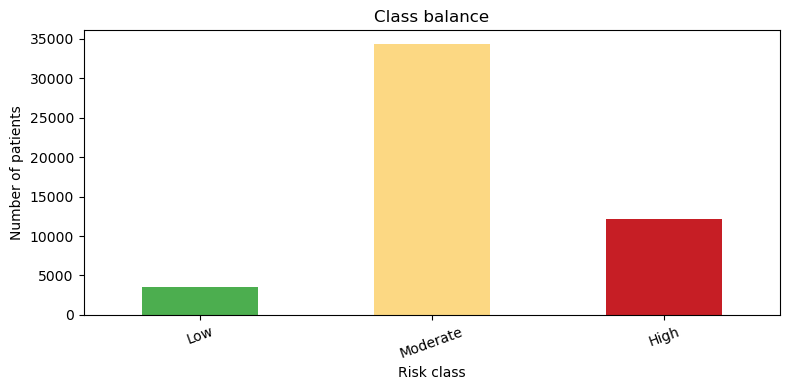

In [5]:
print("Missing values:", int(data.isna().sum().sum()))
display(data.describe(include="all").T)

plt.figure(figsize=(8, 4))

data["Stroke_Risk"].value_counts().reindex(
    ["Low", "Moderate", "High"]
).plot(kind="bar", color=["#4cae4f", "#FCD883", "#C61E25"])
plt.title("Class balance")
plt.xlabel("Risk class")
plt.ylabel("Number of patients")
plt.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

There are `13,522` missing values in the dataset. We use the median-value imputation on numerical columns with missing features.  

In [6]:
numeric_cols = X_train.select_dtypes(include="number").columns
medians = X_train[numeric_cols].median()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_val[numeric_cols] = X_val[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

In [7]:
print("Missing values:", int(X_train[numeric_cols].isna().sum().sum()))
print("Missing values:", int(X_val[numeric_cols].isna().sum().sum()))
print("Missing values:", int(X_test[numeric_cols].isna().sum().sum()))

Missing values: 0
Missing values: 0
Missing values: 0


In [8]:
# Select only columns with categorical dtype
categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns
missing = X_train[categorical_cols].isna().sum()
display(missing[missing > 0])


Medication_Adherence    754
dtype: int64

We see that in our training data, only the `Medication_Adherence` column has missing values. We use "Missing" to impute the missing values in this column.

In [9]:
column = "Medication_Adherence"

for frame in (X_train, X_val, X_test):
    frame[column] = frame[column].fillna("Missing")

print("Missing training categorical values: ", X_train[categorical_cols].isna().sum().sum())
print("Missing validation categorical values: ", X_val[categorical_cols].isna().sum().sum())
print("Missing test categorical values: ", X_test[categorical_cols].isna().sum().sum())

Missing training categorical values:  0
Missing validation categorical values:  0
Missing test categorical values:  0


### One-hot encoding and Scaling

We standardize numerical columns so differences in units do not dominate the models. We one-hot encode categorical columns because assigning category numbers could imply an order. We keep these indicators at 0/1 so rare categories do not get larger weights from standardization. This gives numerical features more variance per column, which can affect what PCA and the autoencoder preserve. We fit both transformations on the training set only.

In [10]:
numeric_scaler = StandardScaler()
category_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    dtype=np.float32
)

numeric_scaler.fit(X_train[numeric_cols])
category_encoder.fit(X_train[categorical_cols])

def transform_features(frame):
    numeric_values = numeric_scaler.transform(frame[numeric_cols])
    categorical_values = category_encoder.transform(frame[categorical_cols])
    return np.hstack([numeric_values, categorical_values]).astype(np.float32)

X_train_processed = transform_features(X_train)
X_val_processed = transform_features(X_val)
X_test_processed = transform_features(X_test)

encoded_category_names = category_encoder.get_feature_names_out(
    categorical_cols
).tolist()
feature_names = numeric_cols.to_list() + encoded_category_names

print("One-hot encoded values:")
display(
    pd.DataFrame(
        category_encoder.transform(X_train[categorical_cols].head()),
        columns=encoded_category_names,
    )
)
print("Model input shape:", X_train_processed.shape)
print("Model feature names:", feature_names)

One-hot encoded values:


,Gender_Female,Gender_Male,Gender_Other,Country_Australia,Country_Bangladesh,Country_Brazil,Country_Canada,Country_China,Country_France,Country_Germany,...,Work_Type_Government,Work_Type_Private,Work_Type_Retired,Work_Type_Self-Employed,Work_Type_Student,Residence_Type_Rural,Residence_Type_Urban,Air_Pollution_Exposure_High,Air_Pollution_Exposure_Low,Air_Pollution_Exposure_Medium
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


Model input shape: (35000, 89)
Model feature names: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Heart_Rate', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Sleep_Hours', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Country_Australia', 'Country_Bangladesh', 'Country_Brazil', 'Country_Canada', 'Country_China', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Indonesia', 'Country_Italy', 'Country_Japan', 'Country_Malaysia', 'Country_Mexico', 'Country_Nigeria', 'Country_Pakistan', 'Country_Russia', 'Country_Saudi Arabia', 'Country_Singapore', 'Country_South Africa', 'Country_South Korea', 'Country_Spain', 'Country_Turkey', 'Country_UAE', 'Country_United Kingdom', 'Country_United States', 'Smoking_Status_Current', 'Smoking_Status_Former', 'Smoking_Status_Never', 'Alcohol_Consumption_Frequently', 'Alcohol_Consumption_Never', 'Alcohol_Consu

In [11]:
def one_hot_targets(frame):
    class_indices = torch.tensor(
        frame.map(CLASS_TO_INDEX).to_numpy(),
        dtype=torch.long,
    )
    return F.one_hot(
        class_indices,
        num_classes=len(CLASS_NAMES),
    ).to(torch.float32)


y_train_processed = one_hot_targets(y_train)
y_val_processed = one_hot_targets(y_val)
y_test_processed = one_hot_targets(y_test)

sample_labels = y_train.iloc[:5]

target_demo = pd.DataFrame({
    "original_label": sample_labels.to_numpy(),
    "class_index": sample_labels.map(CLASS_TO_INDEX).to_numpy(),
    "one_hot_vector": y_train_processed[:5].tolist(),
})

display(target_demo)

print(
    "Each one-hot row sums to:",
    y_train_processed[:5].sum(dim=1).tolist(),
)

,original_label,class_index,one_hot_vector
0,Moderate,1,"[0.0, 1.0, 0.0]"
1,High,2,"[0.0, 0.0, 1.0]"
2,Moderate,1,"[0.0, 1.0, 0.0]"
3,High,2,"[0.0, 0.0, 1.0]"
4,Moderate,1,"[0.0, 1.0, 0.0]"


Each one-hot row sums to: [1.0, 1.0, 1.0, 1.0, 1.0]


### Defining n and choosing k

After preprocessing, we now have 89 input features `n`. Now, we choose candidate dimensions for `k`, which represents the number of features in the compressed representation. Each candidate `k` must satisfy `1 <= k < n`.

In [12]:
n = X_train_processed.shape[1]
candidate_dimensions = [2, 15, 45, 70]
print("n =", n)
print("Candidate Dimensions:", candidate_dimensions)

n = 89
Candidate Dimensions: [2, 15, 45, 70]


## Building a classifier

We use all 89 preprocessed features to train our baseline classifier. The network has one hidden layer with 8 neurons and a ReLU activation, followed by an output layer with 3 neurons for Low, Moderate, and High. We keep this small network as our starting point for the PCA and autoencoder comparisons.

We use cross-entropy loss for this multiclass task. The output layer returns raw logits, and we apply softmax when we want class probabilities. We pass the logits directly to `CrossEntropyLoss`, which handles the log-softmax calculation. Our one-hot targets are valid probability targets for this loss. See the [PyTorch documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

### Training settings and evaluation metric

We use macro F1 as our primary classification metric. About 69% of the training records are Moderate, while only about 7% are Low. A classifier could get many predictions right by favoring Moderate and still perform poorly on Low. Macro F1 calculates F1 for each class and gives the three classes equal weight. Higher values are better, with 1 as the highest possible score. We also report accuracy, macro precision, macro recall, and the scores for each class. The [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) describes how this average is calculated.

We use Adam at a learning rate of 0.001 and a batch size of 32. Each run completes all 80 epochs, following the [Colab example](https://colab.research.google.com/drive/1qKrAUnRzucSWIL8cPYRNyvIZWsg9I3Aq#scrollTo=a198c42a). We save the weights whenever validation loss decreases and restore the checkpoint with the lowest validation loss after training. If two epochs have the same loss, we keep the earlier one. We use validation loss to choose the checkpoint and macro F1 to compare the final classifiers. We use unweighted cross-entropy, with no dropout or weight decay.

The split seed stays at 42. We train fresh models with seeds 42, 43, and 44, which control weight initialization and training-data shuffling. We choose seed 42 now for the detailed classification report and confusion matrix. We will reuse these settings and seeds for each reduced representation, changing only the classifier's input width. The autoencoders will also need separate training runs for these seeds. Test evaluation comes after we finish choosing the PCA and autoencoder configurations.

In [13]:
CLASSIFIER_SEEDS = [42, 43, 44]
REPORT_SEED = 42
HIDDEN_FEATURES = 8
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 80

# Use the CPU and one thread for these small networks.
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

classifier_settings = pd.Series({
    "Architecture": f"{n} inputs -> {HIDDEN_FEATURES} ReLU neurons -> 3 logits",
    "Output probabilities": "Softmax over the 3 classes",
    "Loss": "Unweighted cross-entropy with one-hot targets",
    "Optimizer": "Adam (betas=(0.9, 0.999), eps=1e-8, weight_decay=0)",
    "Learning rate": LEARNING_RATE,
    "Batch size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Stopping rule": f"Complete all {EPOCHS} epochs",
    "Checkpoint": "Lowest validation loss; earlier epoch on a tie",
    "Split seed": SEED,
    "Training seeds": CLASSIFIER_SEEDS,
    "Detailed-report seed": REPORT_SEED,
    "Device": "CPU",
}, name="Setting")
display(classifier_settings.to_frame())

,Setting
Architecture,89 inputs -> 8 ReLU neurons -> 3 logits
Output probabilities,Softmax over the 3 classes
Loss,Unweighted cross-entropy with one-hot targets
Optimizer,"Adam (betas=(0.9, 0.999), eps=1e-8, weight_dec..."
Learning rate,0.001
Batch size,32
Epochs,80
Stopping rule,Complete all 80 epochs
Checkpoint,Lowest validation loss; earlier epoch on a tie
Split seed,42


### Preparing batches

We pair each input row with its one-hot target using `TensorDataset`. The training loader shuffles the rows each epoch. We create a fresh seeded loader for each run so its shuffle order does not depend on earlier runs. Validation and test loaders keep the original row order. We prepare the test loader here for the final comparison later.

In [14]:
train_dataset = TensorDataset(torch.from_numpy(X_train_processed), y_train_processed)
validation_dataset = TensorDataset(torch.from_numpy(X_val_processed), y_val_processed)
test_dataset = TensorDataset(torch.from_numpy(X_test_processed), y_test_processed)


def make_loaders(train_data, validation_data, seed):
    shuffle_generator = torch.Generator().manual_seed(seed)
    return (
        DataLoader(
            train_data,
            batch_size=BATCH_SIZE,
            shuffle=True,
            generator=shuffle_generator,
        ),
        DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False),
    )


train_loader, validation_loader = make_loaders(
    train_dataset, validation_dataset, SEED
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
feature_batch, target_batch = next(iter(train_loader))

print("Feature batch shape:", feature_batch.shape)
print("Target batch shape: ", target_batch.shape)
print("One feature row has", feature_batch.shape[1], "values.")

Feature batch shape: torch.Size([32, 89])
Target batch shape:  torch.Size([32, 3])
One feature row has 89 values.


In [15]:
class TriageNetwork(nn.Module):
    def __init__(self, input_features, hidden_features=8, number_of_classes=3):
        super().__init__()
        self.hidden = nn.Linear(input_features, hidden_features)
        self.activation = nn.ReLU()
        self.output = nn.Linear(hidden_features, number_of_classes)

    def forward(self, x):
        hidden_values = self.activation(self.hidden(x))
        logits = self.output(hidden_values)
        return logits


torch.manual_seed(SEED)
example_model = TriageNetwork(
    input_features=len(feature_names),
    hidden_features=HIDDEN_FEATURES,
    number_of_classes=len(CLASS_NAMES),
)

print(example_model)
print()
print("Parameters by tensor:")
for name, parameter in example_model.named_parameters():
    print(f"{name:20s} shape={str(tuple(parameter.shape)):10s} count={parameter.numel()}")

print(
    "Total trainable parameters:",
    sum(p.numel() for p in example_model.parameters() if p.requires_grad),
)

with torch.no_grad():
    example_logits = example_model(feature_batch[:4])

print("Input shape: ", feature_batch[:4].shape)
print("Output shape:", example_logits.shape)
print("Raw logits:")
print(example_logits)

print("Example class probabilities before training:")
print(torch.softmax(example_logits, dim=1))

TriageNetwork(
  (hidden): Linear(in_features=89, out_features=8, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=8, out_features=3, bias=True)
)

Parameters by tensor:
hidden.weight        shape=(8, 89)    count=712
hidden.bias          shape=(8,)       count=8
output.weight        shape=(3, 8)     count=24
output.bias          shape=(3,)       count=3
Total trainable parameters: 747
Input shape:  torch.Size([4, 89])
Output shape: torch.Size([4, 3])
Raw logits:
tensor([[-0.1194, -0.1185,  0.2146],
        [-0.0638, -0.1970,  0.3046],
        [-0.0521, -0.3701,  0.3645],
        [-0.1266, -0.2137,  0.3528]])
Example class probabilities before training:
tensor([[0.2943, 0.2946, 0.4111],
        [0.3011, 0.2636, 0.4353],
        [0.3082, 0.2243, 0.4675],
        [0.2831, 0.2595, 0.4573]])


### Training and validation

For each training batch, we calculate the loss, compute the gradients, and update the weights. At the end of each epoch, we evaluate the model on the validation set without updating its weights. We calculate the classification metrics over the whole validation set. For the loss, we weight each batch by its number of rows so the smaller last batch does not count as much as a full batch.

The function below creates a new classifier and optimizer each time we call it. It reads the input width from the dataset, so we can also use it for the PCA features and frozen autoencoder features later.

In [16]:
def evaluate_classifier(model, loader, loss_function):
    model.eval()
    total_loss = 0.0
    total_rows = 0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in loader:
            logits = model(features)
            loss = loss_function(logits, targets)
            total_loss += loss.item() * len(features)
            total_rows += len(features)
            all_targets.append(targets.argmax(dim=1).cpu().numpy())
            all_predictions.append(logits.argmax(dim=1).cpu().numpy())

    targets = np.concatenate(all_targets)
    predictions = np.concatenate(all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets,
        predictions,
        labels=list(range(len(CLASS_NAMES))),
        average="macro",
        zero_division=0,
    )
    return {
        "loss": total_loss / total_rows,
        "accuracy": accuracy_score(targets, predictions),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "targets": targets,
        "predictions": predictions,
    }


def train_classifier(train_data, validation_data, seed, verbose=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    training_loader, val_loader = make_loaders(train_data, validation_data, seed)

    model = TriageNetwork(
        input_features=train_data.tensors[0].shape[1],
        hidden_features=HIDDEN_FEATURES,
        number_of_classes=len(CLASS_NAMES),
    )
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
    )
    history = []
    best_validation_loss = float("inf")
    best_state = None
    best_epoch = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        total_rows = 0
        for features, targets in training_loader:
            optimizer.zero_grad()
            logits = model(features)
            loss = loss_function(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(features)
            total_rows += len(features)

        validation = evaluate_classifier(model, val_loader, loss_function)
        history.append({
            "epoch": epoch,
            "train_loss": total_loss / total_rows,
            "validation_loss": validation["loss"],
            "validation_macro_f1": validation["macro_f1"],
        })

        if validation["loss"] < best_validation_loss:
            best_validation_loss = validation["loss"]
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(
                f"Seed {seed}, epoch {epoch:3d}: "
                f"train loss={history[-1]['train_loss']:.4f}, "
                f"validation loss={validation['loss']:.4f}, "
                f"validation macro F1={validation['macro_f1']:.4f}"
            )

    model.load_state_dict(best_state)
    validation = evaluate_classifier(model, val_loader, loss_function)
    return {
        "seed": seed,
        "model": model,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "epochs_trained": len(history),
        "validation": validation,
    }

In [17]:
baseline_runs = {}
for seed in CLASSIFIER_SEEDS:
    run = train_classifier(train_dataset, validation_dataset, seed, verbose=True)
    baseline_runs[seed] = run
    print(
        f"Seed {seed}: trained for {run['epochs_trained']} epochs, "
        f"restored epoch {run['best_epoch']} with the lowest validation loss, "
        f"validation macro F1={run['validation']['macro_f1']:.4f}\n"
    )

# Keep all three models for the final comparison, without choosing a best seed.
baseline_models = {seed: run["model"] for seed, run in baseline_runs.items()}
baseline_model = baseline_models[REPORT_SEED]

Seed 42, epoch   1: train loss=0.5107, validation loss=0.3347, validation macro F1=0.7320


Seed 42, epoch  10: train loss=0.3183, validation loss=0.3125, validation macro F1=0.7936


Seed 42, epoch  20: train loss=0.3156, validation loss=0.3084, validation macro F1=0.7892


Seed 42, epoch  30: train loss=0.3148, validation loss=0.3096, validation macro F1=0.7964


Seed 42, epoch  40: train loss=0.3139, validation loss=0.3086, validation macro F1=0.7952


...

Seed 44, epoch  40: train loss=0.2990, validation loss=0.2930, validation macro F1=0.8051


Seed 44, epoch  50: train loss=0.2947, validation loss=0.2922, validation macro F1=0.8132


Seed 44, epoch  60: train loss=0.2945, validation loss=0.2948, validation macro F1=0.8158


Seed 44, epoch  70: train loss=0.2937, validation loss=0.2919, validation macro F1=0.8156


Seed 44, epoch  80: train loss=0.2926, validation loss=0.2923, validation macro F1=0.8171
Seed 44: trained for 80 epochs, restored epoch 52 with the lowest validation loss, validation macro F1=0.8144



### Baseline validation results

We report every seed and calculate the mean and sample standard deviation (`ddof=1`) across the three runs. These values describe how much training varies on our fixed split. They do not measure uncertainty across different samples of patients.

In [18]:
metric_names = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
baseline_results = pd.DataFrame([
    {
        "seed": seed,
        "best_epoch": run["best_epoch"],
        "epochs_trained": run["epochs_trained"],
        "validation_loss": run["validation"]["loss"],
        **{metric: run["validation"][metric] for metric in metric_names},
    }
    for seed, run in baseline_runs.items()
]).set_index("seed")

print("Validation scores for each seed:")
display(baseline_results.round(4))

baseline_summary = baseline_results[metric_names].agg(["mean", "std"]).T
baseline_summary["mean +/- std"] = [
    f"{row['mean']:.4f} +/- {row['std']:.4f}"
    for _, row in baseline_summary.iterrows()
]
print("Validation scores across seeds (higher is better):")
display(baseline_summary)

baseline_validation_f1_mean = baseline_summary.loc["macro_f1", "mean"]
baseline_validation_f1_std = baseline_summary.loc["macro_f1", "std"]
print(
    f"Baseline validation macro F1: {baseline_validation_f1_mean:.4f} "
    f"+/- {baseline_validation_f1_std:.4f}"
)

Validation scores for each seed:


,best_epoch,epochs_trained,validation_loss,accuracy,macro_precision,macro_recall,macro_f1
seed,,,,,,,
42,59,80,0.2974,0.8728,0.8361,0.7790,0.8039
43,78,80,0.2929,0.8700,0.8306,0.7868,0.8069
44,52,80,0.2905,0.8751,0.8403,0.7930,0.8144


Validation scores across seeds (higher is better):


,mean,std,mean +/- std
accuracy,0.872622,0.002538,0.8726 +/- 0.0025
macro_precision,0.835652,0.004847,0.8357 +/- 0.0048
macro_recall,0.786243,0.007011,0.7862 +/- 0.0070
macro_f1,0.808412,0.005399,0.8084 +/- 0.0054


Baseline validation macro F1: 0.8084 +/- 0.0054


### Learning curves

The training loss below is the mean loss from the batches used to update the weights during each epoch. We calculate validation loss after the epoch. The dotted lines on the loss plots and the dots on the macro F1 curves mark the epochs with the lowest validation loss for each seed. These epochs may differ from the ones with the highest macro F1.

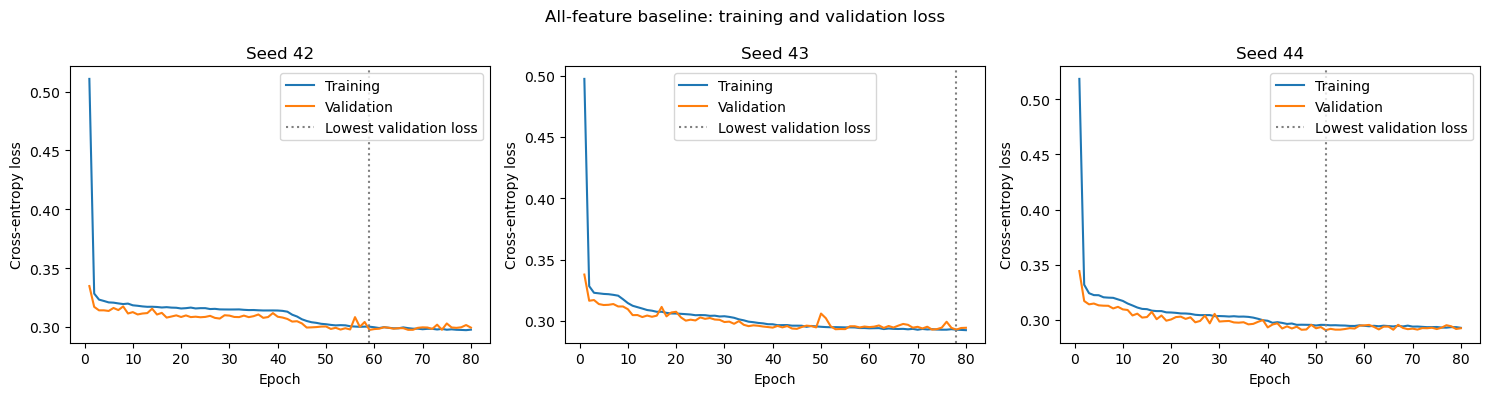

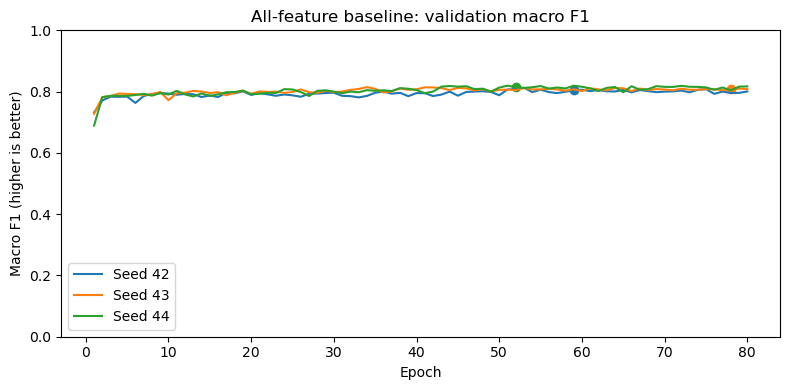

In [19]:
fig, axes = plt.subplots(1, len(CLASSIFIER_SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, CLASSIFIER_SEEDS):
    run = baseline_runs[seed]
    history = run["history"]
    ax.plot(history["epoch"], history["train_loss"], label="Training")
    ax.plot(history["epoch"], history["validation_loss"], label="Validation")
    ax.axvline(run["best_epoch"], color="gray", linestyle=":", label="Lowest validation loss")
    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
fig.suptitle("All-feature baseline: training and validation loss")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for seed, run in baseline_runs.items():
    history = run["history"]
    line, = ax.plot(
        history["epoch"], history["validation_macro_f1"], label=f"Seed {seed}"
    )
    ax.scatter(
        run["best_epoch"], run["validation"]["macro_f1"], color=line.get_color()
    )
ax.set_title("All-feature baseline: validation macro F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1 (higher is better)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Class-specific results

We use the checkpoint from seed 42 for the detailed report and confusion matrix, as chosen before training. Rows in the confusion matrix are the true classes, and columns are the predicted classes. The normalized matrix shows the fraction of each true class assigned to each predicted class, which makes errors in the smaller Low class easier to see.

Validation classification report (seed 42):


,precision,recall,f1-score,support
Low,0.7826,0.6148,0.6886,527.0
Moderate,0.8927,0.9263,0.9092,5156.0
High,0.8329,0.7958,0.8140,1817.0
macro avg,0.8361,0.7790,0.8039,7500.0
weighted avg,0.8705,0.8728,0.8706,7500.0


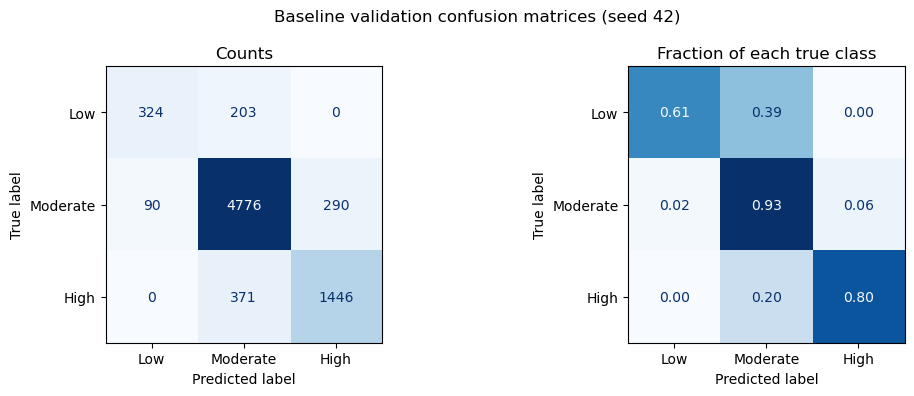

In [20]:
report_validation = baseline_runs[REPORT_SEED]["validation"]
validation_targets = report_validation["targets"]
validation_predictions = report_validation["predictions"]
class_indices = list(range(len(CLASS_NAMES)))

baseline_classification_report = pd.DataFrame(classification_report(
    validation_targets,
    validation_predictions,
    labels=class_indices,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)).T.drop(index="accuracy")
print(f"Validation classification report (seed {REPORT_SEED}):")
display(baseline_classification_report.round(4))

baseline_confusion_matrix = confusion_matrix(
    validation_targets, validation_predictions, labels=class_indices
)
normalized_confusion_matrix = confusion_matrix(
    validation_targets,
    validation_predictions,
    labels=class_indices,
    normalize="true",
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, matrix, title, value_format in (
    (axes[0], baseline_confusion_matrix, "Counts", "d"),
    (axes[1], normalized_confusion_matrix, "Fraction of each true class", ".2f"),
):
    ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", values_format=value_format, colorbar=False
    )
    ax.set_title(title)
fig.suptitle(f"Baseline validation confusion matrices (seed {REPORT_SEED})")
plt.tight_layout()
plt.show()

Across the three seeds, we get a validation macro F1 of 0.8084 +/- 0.0054 and a mean accuracy of 87.26%. All three models train for 80 epochs. The lowest-validation-loss checkpoints are epochs 59, 78, and 52 for seeds 42, 43, and 44, respectively.

In the seed-42 report, F1 is 0.9092 for Moderate, 0.8140 for High, and 0.6886 for Low. The model correctly identifies 324 of the 527 Low records and labels 203 as Moderate. It also labels 371 of the 1,817 High records as Moderate. The overall accuracy does not show these differences between classes, so we will use macro F1 to compare this baseline with the reduced representations.

We keep `baseline_runs`, `baseline_results`, and `baseline_summary` for the comparisons with PCA and the autoencoder. Each run contains its selected model and validation results. We will evaluate all three selected baseline models on the test set once the choices for the other methods are fixed.

In [21]:
import platform
from importlib.metadata import version

print("Python:", platform.python_version())
print("Device: CPU; PyTorch threads:", torch.get_num_threads())
display(pd.Series(
    {package: version(package) for package in (
        "torch", "numpy", "pandas", "scikit-learn", "matplotlib"
    )},
    name="Version",
).to_frame())

Python: 3.13.9
Device: CPU; PyTorch threads: 1


,Version
torch,2.12.0
numpy,2.3.5
pandas,2.3.3
scikit-learn,1.7.2
matplotlib,3.10.6
